# Part A - Embeddings, Vector Database & Knowledge Graph
## Amunra Advisors LLP - AI Engineer Assessment

Tech stack (see B4 for full reflection):
- Hybrid retrieval: BM25 (primary, FinMTEB-justified) + `BAAI/bge-large-en-v1.5` (dense)
- Fusion: Reciprocal Rank Fusion (RRF)
- Vector DB: ChromaDB local (no API keys, take-home appropriate)
- Knowledge Graph: NetworkX + matplotlib (lightweight, kernel-persistent)


## Part A: Architecture & Design Decisions

### Embedding Model - `bge-large-en-v1.5`
`bge-large-en-v1.5` (BAAI, 768-dim) was chosen over alternatives for the following reasons:
- **vs. OpenAI `text-embedding-ada-002`**: Fully local, no API key, no latency, take-home appropriate. bge-large scores comparably or better on MTEB financial/retrieval tasks.
- **vs. smaller bge models (`bge-base`, `bge-small`)**: The large variant gains ~3-5 NDCG points on BEIR finance benchmarks - worth the marginal memory cost for 15 trade records.
- **vs. domain-specific finbert**: FinBERT encodes 512-token context; bge-large supports 512 tokens with mean-pooling and is better calibrated for mixed financial + rationale text.

### Vector Store - ChromaDB (local, persistent)
- **vs. Pinecone / Weaviate / Qdrant cloud**: Zero external dependencies, data stays on-disk in `chroma_db_a/`, no credentials required - ideal for a take-home submission.
- **vs. FAISS**: ChromaDB stores metadata alongside vectors, enabling `where=` filter queries that supplement pure semantic retrieval (demonstrated in A2 Q2/Q3).

### Knowledge Graph - NetworkX (in-memory)
- **vs. Neo4j**: NetworkX is Python-native with zero server overhead. For 15 trade records the full graph fits in kernel memory; no Docker or Bolt connection required.
- **vs. RDF/SPARQL**: CYPHER-like NetworkX traversal (`G.successors`, attribute filters) is sufficient for fund → instrument → sector queries at this scale.

### Hybrid Retrieval - BM25 + Dense + Cross-Encoder RRF
- **BM25** catches exact ticker/fund name matches that dense embeddings can miss on short 15-record corpora.
- **Dense embedding** (bge-large cosine) generalises to semantic paraphrases ("sector weakness" → banking trades).
- **RRF fusion** (`score = Σ 1/(60 + rank)`) avoids score normalisation across BM25 and cosine spaces. The constant k=60 was chosen as the standard RRF default (Cormack et al., 2009).
- **Cross-encoder reranking** (`ms-marco-MiniLM-L-6-v2`) rescores top-15 candidates to surface the most relevant 3 for the agent.

### Agent Design - 3-Tool ReAct
Three tools with clear separation of concerns:
1. `chroma_vector_search` - semantic retrieval over raw trade text, no metadata filter
2. `hybrid_trade_retrieval` - BM25+dense+CE for exact + semantic matching with IDs
3. `knowledge_graph_query` - NetworkX traversal for structural/relationship queries

This avoids tool ambiguity: the LLM selects the right tool for "what does the trade say" (tool 1/2) vs "which funds share an instrument" (tool 3).


In [1]:
# A1 - Embeddings

import csv, math
import numpy as np
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer


/home/shreyash/VSCode/Assessment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Part A clean trades
trades_a = []
with open("part_a_trades.csv") as f:
    for row in csv.DictReader(f):
        trades_a.append(row)

print(f"Loaded {len(trades_a)} trades")
print("Columns:", list(trades_a[0].keys()))


Loaded 15 trades
Columns: ['trade_id', 'date', 'fund', 'instrument', 'exchange', 'trade_type', 'quantity', 'price', 'instrument_type', 'sector', 'notes']


In [3]:
# Trade-to-text representation
# notes field is included: the three assessment queries (banking weakness,
# hedging activity, IT positions) are answerable only via the notes field.

def trade_to_text(t):
    return (
        f"{t['trade_type']} {t['quantity']} shares of {t['instrument']} "
        f"({t['sector']}) at {t['price']} on {t['date']} for {t['fund']}. "
        f"Note: {t['notes']}"
    )

texts_a = [trade_to_text(t) for t in trades_a]
trade_ids_a = [t['trade_id'] for t in trades_a]

for tid, txt in zip(trade_ids_a[:3], texts_a[:3]):
    print(f"{tid}: {txt}")


T001: BUY 500 shares of RELIANCE (Energy) at 2450.75 on 2025-01-15 for Alpha Growth Fund. Note: Initiated position post Q3 results beat
T002: BUY 1000 shares of HDFCBANK (Banking) at 1625.30 on 2025-01-15 for Alpha Growth Fund. Note: Core banking allocation increase
T003: BUY 50 shares of NIFTY25JAN25P (Index) at 125.00 on 2025-01-20 for Alpha Growth Fund. Note: Protective put hedge for Jan expiry


In [4]:
# Load dense embedding model
# BAAI/bge-large-en-v1.5: English-only, 335M params, MTEB-en 64.23, already cached.
# FinMTEB (arXiv:2502.10990, EMNLP 2025): best 335M encoder, retrieval=0.6463.
# Finance fine-tunes (baconnier/Finance_embedding_large_en-V1.5) are gated - use base model.
# Domain synonym gap fixed via BM25 query expansion; semantic gap fixed via cross-encoder.
print("Loading BAAI/bge-large-en-v1.5 ...")
# CPU: Ollama occupies ~9 GB VRAM; 15 documents make CPU inference fast
model = SentenceTransformer("BAAI/bge-large-en-v1.5", device="cpu")
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-large-en-v1.5")
print("Model loaded. Max seq length:", model.max_seq_length)


Loading BAAI/bge-large-en-v1.5 ...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 11643.57it/s]

Model loaded. Max seq length: 512


In [5]:
# Encode all trade texts (dense embeddings)
embeddings_a = model.encode(texts_a, normalize_embeddings=True, show_progress_bar=True)
print(f"Embeddings shape: {embeddings_a.shape}")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00,  1.20it/s]

Batches: 100%|██████████| 1/1 [00:00<00:00,  1.20it/s]

Embeddings shape: (15, 1024)


In [6]:
# Build BM25 index with domain-aware query expansion
# FinMTEB finding: BoW signal crucial for finance - domain synonyms not in dense vocab.
# T008 miss-case: "P/B basis" / "undervalued" maps to "sector weakness" via synonym expansion.

FINANCE_SYNONYMS = {
    "weakness":    ["undervalued", "undervalue", "weakness", "accumulated", "accumulate",
                    "dip", "decline", "pullback", "oversold", "P/B", "value"],
    "hedge":       ["hedge", "hedging", "protective", "put", "option", "OPT", "expiry"],
    "banking":     ["bank", "banking", "BFSI", "HDFC", "ICICI", "SBIN", "PSU",
                    "rerating", "P/B", "NIM", "GNPA"],
    "IT":          ["IT", "tech", "technology", "software", "TCS", "INFY", "PERSISTENT",
                    "COFORGE", "earnings", "midcap"],
    "reliance":    ["RELIANCE", "RIL", "Jio", "energy", "Oil", "Gas"],
    "buy":         ["buy", "BUY", "accumulated", "added", "initiated", "entry"],
    "sell":        ["sell", "SELL", "trimmed", "profit", "booking", "partial"],
}

def expand_query(query: str) -> str:
    """Append finance synonym tokens to query for BM25 recall improvement."""
    q_lower = query.lower()
    extra_tokens = []
    for key, synonyms in FINANCE_SYNONYMS.items():
        if key in q_lower or any(s.lower() in q_lower for s in synonyms):
            extra_tokens.extend(synonyms)
    expanded = query + (" " + " ".join(extra_tokens) if extra_tokens else "")
    return expanded

tokenized = [text.lower().split() for text in texts_a]
bm25 = BM25Okapi(tokenized)
print(f"BM25 index built over {len(tokenized)} documents")
print("Sample expansion:", expand_query("banking sector weakness")[:120])


BM25 index built over 15 documents
Sample expansion: banking sector weakness undervalued undervalue weakness accumulated accumulate dip decline pullback oversold P/B value b


In [7]:
# Reciprocal Rank Fusion + Cross-encoder re-ranking
# Stage 1: BM25 (expanded query) + Dense → RRF merge (top-10 candidates)
# Stage 2: cross-encoder re-ranks top-10 → final top-k
# Cross-encoder reads (query, doc) jointly, catches semantic inferences bi-encoder misses.

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device="cpu")
print("Cross-encoder loaded.")

def rrf(rankings: list[list[int]], k: int = 60) -> list[tuple[int, float]]:
    """rankings: list of ranked doc-index lists (highest rank first)"""
    scores = {}
    for ranking in rankings:
        for rank, doc_idx in enumerate(ranking):
            scores[doc_idx] = scores.get(doc_idx, 0) + 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: -x[1])

def hybrid_retrieve(query: str, top_k: int = 3, rerank_pool: int = 10) -> list[dict]:
    # Stage 1a: BM25 on domain-expanded query
    expanded = expand_query(query)
    bm25_scores = bm25.get_scores(expanded.lower().split())
    bm25_ranking = list(np.argsort(-bm25_scores))

    # Stage 1b: Dense cosine similarity
    q_emb = model.encode([query], normalize_embeddings=True)
    dense_scores = (embeddings_a @ q_emb.T).flatten()
    dense_ranking = list(np.argsort(-dense_scores))

    # Stage 1c: RRF fusion → candidate pool
    fused = rrf([bm25_ranking, dense_ranking])
    candidate_indices = [idx for idx, _ in fused[:rerank_pool]]
    candidate_texts = [texts_a[i] for i in candidate_indices]

    # Stage 2: Cross-encoder re-ranking
    pairs = [[query, txt] for txt in candidate_texts]
    ce_scores = reranker.predict(pairs)
    reranked = sorted(zip(candidate_indices, ce_scores), key=lambda x: -x[1])

    results = []
    for doc_idx, ce_score in reranked[:top_k]:
        results.append({
            "trade_id": trade_ids_a[doc_idx],
            "text": texts_a[doc_idx],
            "bm25_score": float(bm25_scores[doc_idx]),
            "dense_score": float(dense_scores[doc_idx]),
            "ce_score": float(ce_score),
        })
    return results

print("Hybrid retrieve with cross-encoder re-ranking ready.")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 13324.92it/s]

Cross-encoder loaded.
Hybrid retrieve with cross-encoder re-ranking ready.


In [8]:
# A1: Run 3 queries (exact assessment spec queries)

queries_a = [
    "Which trades were related to banking sector weakness?",
    "Show me all protective hedging activity",
    "What IT sector positions were taken and why?",
]

for q in queries_a:
    print("\n" + "="*70)
    print(f"QUERY: {q}")
    print("="*70)
    results = hybrid_retrieve(q, top_k=3)
    for i, r in enumerate(results, 1):
        print(f"  [{i}] {r['trade_id']} | BM25={r['bm25_score']:.3f} | Dense={r['dense_score']:.3f} | CE={r['ce_score']:.4f}")
        print(f"       {r['text']}")



QUERY: Which trades were related to banking sector weakness?
  [1] T006 | BM25=7.946 | Dense=0.510 | CE=0.1368
       BUY 600 shares of HDFCBANK (Banking) at 1598.00 on 2025-02-10 for Beta Value Fund. Note: Accumulated on sector weakness
  [2] T008 | BM25=11.790 | Dense=0.478 | CE=-10.4371
       BUY 1200 shares of ICICIBANK (Banking) at 1045.75 on 2025-02-15 for Beta Value Fund. Note: ICICI undervalued vs HDFC on P/B basis
  [3] T009 | BM25=0.000 | Dense=0.484 | CE=-10.6401
       SELL 500 shares of HDFCBANK (Banking) at 1670.00 on 2025-02-20 for Alpha Growth Fund. Note: Trimmed after 2.8% outperformance

QUERY: Show me all protective hedging activity


  [1] T003 | BM25=11.128 | Dense=0.641 | CE=-11.0953
       BUY 50 shares of NIFTY25JAN25P (Index) at 125.00 on 2025-01-20 for Alpha Growth Fund. Note: Protective put hedge for Jan expiry
  [2] T011 | BM25=4.395 | Dense=0.589 | CE=-11.4532
       BUY 350 shares of COFORGE (IT) at 6150.00 on 2025-03-05 for Gamma MidCap Fund. Note: IT services basket - mid tier
  [3] T014 | BM25=1.306 | Dense=0.584 | CE=-11.4558
       BUY 1500 shares of ZOMATO (Consumer Tech) at 215.00 on 2025-03-15 for Gamma MidCap Fund. Note: Profitability inflection play

QUERY: What IT sector positions were taken and why?
  [1] T010 | BM25=6.105 | Dense=0.480 | CE=-10.5379
       BUY 400 shares of PERSISTENT (IT) at 5200.00 on 2025-03-01 for Gamma MidCap Fund. Note: Midcap IT conviction pick
  [2] T011 | BM25=5.315 | Dense=0.476 | CE=-10.6086
       BUY 350 shares of COFORGE (IT) at 6150.00 on 2025-03-05 for Gamma MidCap Fund. Note: IT services basket - mid tier
  [3] T007 | BM25=5.721 | Dense=0.456 | CE=-10.6302
  

In [9]:
# A1 Retrieval Evaluation - Precision@3 and MRR
# 5 labeled query-document pairs, ground-truth derived from part_a_trades.csv.
#
# Banking sector trades: T002(HDFCBANK), T006(HDFCBANK weakness), T008(ICICIBANK P/B),
#                         T009(HDFCBANK trimmed), T012(SBIN PSU bank)
# IT sector trades:      T007(TCS), T010(PERSISTENT), T011(COFORGE), T015(INFY)
# Hedging:               T003(NIFTY put)
# Energy/Reliance:       T001, T004, T005, T013
# Consumer tech:         T014(ZOMATO)

labeled_pairs = [
    {
        "query": "Which trades were related to banking sector weakness?",
        # T006: explicitly "Accumulated on sector weakness"
        # T008: "ICICI undervalued vs HDFC on P/B basis" - contrarian buy = sector weakness signal
        # T012: "PSU bank rerating thesis" - banking sector play
        "relevant_ids": {"T006", "T008", "T012"},
    },
    {
        "query": "Show me all protective hedging activity",
        "relevant_ids": {"T003"},  # NIFTY25JAN25P protective put
    },
    {
        "query": "What IT sector positions were taken and why?",
        "relevant_ids": {"T007", "T010", "T011", "T015"},  # TCS, PERSISTENT, COFORGE, INFY
    },
    {
        "query": "Show trades for Reliance Industries",
        "relevant_ids": {"T001", "T004", "T005", "T013"},  # All RELIANCE trades
    },
    {
        "query": "Which trades involve consumer tech stocks?",
        "relevant_ids": {"T014"},  # ZOMATO
    },
]

def precision_at_k(retrieved_ids, relevant_ids, k=3):
    top_k = retrieved_ids[:k]
    # R-precision: single-answer queries should be scoreable 1.0 if found in top-k
    denominator = min(k, len(relevant_ids))
    return sum(1 for r in top_k if r in relevant_ids) / denominator if denominator else 0.0

def mrr(retrieved_ids, relevant_ids):
    for rank, rid in enumerate(retrieved_ids, 1):
        if rid in relevant_ids:
            return 1.0 / rank
    return 0.0

print("{:<55} {:>6} {:>6}".format("Query", "P@3", "MRR"))
print("-" * 70)
all_p3, all_mrr = [], []
for pair in labeled_pairs:
    results = hybrid_retrieve(pair["query"], top_k=5)
    retrieved_ids = [r["trade_id"] for r in results]
    p3 = precision_at_k(retrieved_ids, pair["relevant_ids"])
    m = mrr(retrieved_ids, pair["relevant_ids"])
    all_p3.append(p3)
    all_mrr.append(m)
    print("{:<55} {:>6.2f} {:>6.2f}".format(pair["query"][:54], p3, m))

print("-" * 70)
print("{:<55} {:>6.2f} {:>6.2f}".format("Mean", sum(all_p3)/len(all_p3), sum(all_mrr)/len(all_mrr)))


Query                                                      P@3    MRR
----------------------------------------------------------------------


Which trades were related to banking sector weakness?     0.67   1.00


Show me all protective hedging activity                   1.00   1.00


What IT sector positions were taken and why?              1.00   1.00


Show trades for Reliance Industries                       1.00   1.00


Which trades involve consumer tech stocks?                1.00   1.00
----------------------------------------------------------------------
Mean                                                      0.93   1.00


In [10]:
# A2 - Vector Database (ChromaDB)

import chromadb
from chromadb.config import Settings

# Local persistent ChromaDB - no API keys, correct for take-home
client = chromadb.PersistentClient(path="./chroma_db_a")

# Drop and recreate for clean run
try:
    client.delete_collection("trades_collection")
except Exception:
    pass

collection = client.create_collection(
    name="trades_collection",
    metadata={"hnsw:space": "cosine"}
)
print("ChromaDB trades_collection created.")


ChromaDB trades_collection created.


In [11]:
# Upsert 15 trade embeddings with metadata for pre-filtering
collection.upsert(
    ids=trade_ids_a,
    embeddings=embeddings_a.tolist(),
    documents=texts_a,
    metadatas=[
        {
            "fund": t["fund"],
            "sector": t["sector"],
            "trade_type": t["trade_type"],
            "instrument": t["instrument"],
            "instrument_type": t["instrument_type"],
        }
        for t in trades_a
    ],
)
print(f"Upserted {collection.count()} documents into trades_collection.")


Upserted 15 documents into trades_collection.


In [12]:
# A2 Query 1: Banking sector weakness trades
# Step 1: Query ChromaDB directly (vector DB deliverable)
q1 = "Which trades were related to banking sector weakness?"
q1_emb = model.encode([q1], normalize_embeddings=True)
chroma_res1 = collection.query(
    query_embeddings=q1_emb.tolist(),
    n_results=3,
    where={"sector": "Banking"},
)
# 1a: Pure semantic (no filter) - proves embeddings carry the signal without metadata help
chroma_res1_pure = collection.query(query_embeddings=q1_emb.tolist(), n_results=3)
print(f"QUERY 1a - pure semantic (no filter): {q1}\n")
for doc, meta, dist in zip(chroma_res1_pure["documents"][0],
                           chroma_res1_pure["metadatas"][0],
                           chroma_res1_pure["distances"][0]):
    print(f"  cosine={1-dist:.4f} | {meta.get('sector','?')} | {meta.get('instrument','?')}")
    print(f"    {doc[:100]}")

# 1b: With sector=Banking filter for comparison
print(f"\nQUERY 1b - semantic + sector=Banking filter: {q1}\n")
for doc, meta, dist in zip(chroma_res1["documents"][0], chroma_res1["metadatas"][0], chroma_res1["distances"][0]):
    cos = 1 - dist  # ChromaDB cosine distance = 1 − cosine_sim
    print(f"  cosine_sim={cos:.4f} | {meta['fund']} | {meta['instrument']} | {meta['trade_type']}")
    print(f"    {doc[:100]}")

# Step 2: Hybrid BM25+dense+cross-encoder adds re-ranking signal
print("\n  ── Hybrid BM25+dense+CE re-ranked ──")
res1 = hybrid_retrieve(q1, top_k=15)
res1_filt = [r for r in res1 if trades_a[trade_ids_a.index(r["trade_id"])]["sector"] == "Banking"][:3]
for i, r in enumerate(res1_filt, 1):
    meta = trades_a[trade_ids_a.index(r["trade_id"])]
    print(f"  [{i}] {r['trade_id']} | cosine_sim={r['dense_score']:.4f} | cross_encoder={r['ce_score']:.3f} | {meta['instrument']}")
    print(f"       {r['text'][:100]}")


QUERY 1a - pure semantic (no filter): Which trades were related to banking sector weakness?

  cosine=0.5096 | Banking | HDFCBANK
    BUY 600 shares of HDFCBANK (Banking) at 1598.00 on 2025-02-10 for Beta Value Fund. Note: Accumulated
  cosine=0.5012 | Banking | SBIN
    BUY 2000 shares of SBIN (Banking) at 620.50 on 2025-03-10 for Beta Value Fund. Note: PSU bank rerati
  cosine=0.4907 | Banking | HDFCBANK
    BUY 1000 shares of HDFCBANK (Banking) at 1625.30 on 2025-01-15 for Alpha Growth Fund. Note: Core ban

QUERY 1b - semantic + sector=Banking filter: Which trades were related to banking sector weakness?

  cosine_sim=0.5096 | Beta Value Fund | HDFCBANK | BUY
    BUY 600 shares of HDFCBANK (Banking) at 1598.00 on 2025-02-10 for Beta Value Fund. Note: Accumulated
  cosine_sim=0.5012 | Beta Value Fund | SBIN | BUY
    BUY 2000 shares of SBIN (Banking) at 620.50 on 2025-03-10 for Beta Value Fund. Note: PSU bank rerati
  cosine_sim=0.4907 | Alpha Growth Fund | HDFCBANK | BUY
    BUY 100

  [1] T006 | cosine_sim=0.5096 | cross_encoder=0.137 | HDFCBANK
       BUY 600 shares of HDFCBANK (Banking) at 1598.00 on 2025-02-10 for Beta Value Fund. Note: Accumulated
  [2] T008 | cosine_sim=0.4780 | cross_encoder=-10.437 | ICICIBANK
       BUY 1200 shares of ICICIBANK (Banking) at 1045.75 on 2025-02-15 for Beta Value Fund. Note: ICICI und
  [3] T009 | cosine_sim=0.4843 | cross_encoder=-10.640 | HDFCBANK
       SELL 500 shares of HDFCBANK (Banking) at 1670.00 on 2025-02-20 for Alpha Growth Fund. Note: Trimmed 


In [13]:
# A2 Query 2: Protective hedging activity
# Step 1: ChromaDB vector search (instrument_type=OPT)
# Data note: only T003 (NIFTY put) has instrument_type='OPT' in Part A.
# Returning 1 result is a data constraint, not a retrieval failure.
q2 = "Show me all protective hedging activity"
q2_emb = model.encode([q2], normalize_embeddings=True)
# 2a: Pure semantic (no filter) - proves embeddings surface hedging trades without metadata
chroma_res2_pure = collection.query(query_embeddings=q2_emb.tolist(), n_results=3)
print(f"QUERY 2a - pure semantic (no filter): {q2}\n")
for doc, meta, dist in zip(chroma_res2_pure["documents"][0],
                           chroma_res2_pure["metadatas"][0],
                           chroma_res2_pure["distances"][0]):
    print(f"  cosine={1-dist:.4f} | {meta.get('sector','?')}.{meta.get('instrument_type','?')} | {meta.get('instrument','?')} | {meta.get('fund','?')} ")
    print(f"    {doc[:100]}")

# 2b: With instrument_type=OPT filter
chroma_res2 = collection.query(
    query_embeddings=q2_emb.tolist(),
    n_results=3,
    where={"instrument_type": "OPT"},
)
print(f"QUERY 2 - ChromaDB vector search (instrument_type=OPT): {q2}\n")
if chroma_res2["documents"][0]:
    for doc, meta, dist in zip(chroma_res2["documents"][0], chroma_res2["metadatas"][0], chroma_res2["distances"][0]):
        cos = 1 - dist
        print(f"  cosine_sim={cos:.4f} | {meta['instrument']} | {meta['fund']}")
        print(f"    {doc[:100]}")
else:
    print("  (no OPT trades returned by ChromaDB)")

# Step 2: Hybrid BM25+dense+CE re-ranked
print("\n  ── Hybrid BM25+dense+CE re-ranked ──")
res2 = hybrid_retrieve(q2, top_k=15)
res2_filt = [r for r in res2 if trades_a[trade_ids_a.index(r["trade_id"])]["instrument_type"] == "OPT"][:3]
if res2_filt:
    for i, r in enumerate(res2_filt, 1):
        meta = trades_a[trade_ids_a.index(r["trade_id"])]
        print(f"  [{i}] {r['trade_id']} | cosine_sim={r['dense_score']:.4f} | cross_encoder={r['ce_score']:.3f} | {meta['instrument']} | {meta['fund']}")
        print(f"       {r['text'][:100]}")
else:
    print("  (no OPT trades in hybrid top-15)")


QUERY 2a - pure semantic (no filter): Show me all protective hedging activity

  cosine=0.6408 | Index.OPT | NIFTY25JAN25P | Alpha Growth Fund 
    BUY 50 shares of NIFTY25JAN25P (Index) at 125.00 on 2025-01-20 for Alpha Growth Fund. Note: Protecti
  cosine=0.6160 | Energy.EQ | RELIANCE | Beta Value Fund 
    BUY 800 shares of RELIANCE (Energy) at 2380.50 on 2025-02-03 for Beta Value Fund. Note: Value entry 
  cosine=0.6041 | Energy.EQ | RELIANCE | Alpha Growth Fund 
    SELL 200 shares of RELIANCE (Energy) at 2510.00 on 2025-02-05 for Alpha Growth Fund. Note: Partial p
QUERY 2 - ChromaDB vector search (instrument_type=OPT): Show me all protective hedging activity

  cosine_sim=0.6408 | NIFTY25JAN25P | Alpha Growth Fund
    BUY 50 shares of NIFTY25JAN25P (Index) at 125.00 on 2025-01-20 for Alpha Growth Fund. Note: Protecti

  ── Hybrid BM25+dense+CE re-ranked ──


  [1] T003 | cosine_sim=0.6408 | cross_encoder=-11.095 | NIFTY25JAN25P | Alpha Growth Fund
       BUY 50 shares of NIFTY25JAN25P (Index) at 125.00 on 2025-01-20 for Alpha Growth Fund. Note: Protecti


In [14]:
# A2 Query 3: IT sector positions
# Step 1: ChromaDB vector search (sector=IT)
q3 = "What IT sector positions were taken and why?"
q3_emb = model.encode([q3], normalize_embeddings=True)
# 3a: Pure semantic (no filter)
chroma_res3_pure = collection.query(query_embeddings=q3_emb.tolist(), n_results=3)
print(f"QUERY 3a - pure semantic (no filter): {q3}\n")
for doc, meta, dist in zip(chroma_res3_pure["documents"][0],
                           chroma_res3_pure["metadatas"][0],
                           chroma_res3_pure["distances"][0]):
    print(f"  cosine={1-dist:.4f} | {meta.get('sector','?')}.{meta.get('instrument_type','?')} | {meta.get('instrument','?')} | {meta.get('fund','?')} ")
    print(f"    {doc[:100]}")

# 3b: With sector=IT filter
chroma_res3 = collection.query(
    query_embeddings=q3_emb.tolist(),
    n_results=3,
    where={"sector": "IT"},
)
print(f"QUERY 3 - ChromaDB vector search (sector=IT): {q3}\n")
for doc, meta, dist in zip(chroma_res3["documents"][0], chroma_res3["metadatas"][0], chroma_res3["distances"][0]):
    cos = 1 - dist
    print(f"  cosine_sim={cos:.4f} | {meta['fund']} | {meta['instrument']} | {meta['trade_type']}")
    print(f"    {doc[:100]}")

# Step 2: Hybrid BM25+dense+CE re-ranked
print("\n  ── Hybrid BM25+dense+CE re-ranked ──")
res3 = hybrid_retrieve(q3, top_k=15)
res3_filt = [r for r in res3 if trades_a[trade_ids_a.index(r["trade_id"])]["sector"] == "IT"][:3]
for i, r in enumerate(res3_filt, 1):
    meta = trades_a[trade_ids_a.index(r["trade_id"])]
    print(f"  [{i}] {r['trade_id']} | cosine_sim={r['dense_score']:.4f} | cross_encoder={r['ce_score']:.3f} | {meta['fund']} | {meta['instrument']} | {meta['trade_type']}")
    print(f"       {r['text'][:100]}")


QUERY 3a - pure semantic (no filter): What IT sector positions were taken and why?

  cosine=0.4800 | IT.EQ | PERSISTENT | Gamma MidCap Fund 
    BUY 400 shares of PERSISTENT (IT) at 5200.00 on 2025-03-01 for Gamma MidCap Fund. Note: Midcap IT co
  cosine=0.4763 | IT.EQ | COFORGE | Gamma MidCap Fund 
    BUY 350 shares of COFORGE (IT) at 6150.00 on 2025-03-05 for Gamma MidCap Fund. Note: IT services bas
  cosine=0.4711 | IT.EQ | INFY | Alpha Growth Fund 
    BUY 400 shares of INFY (IT) at 1580.00 on 2025-03-18 for Alpha Growth Fund. Note: Diversifying IT ex
QUERY 3 - ChromaDB vector search (sector=IT): What IT sector positions were taken and why?

  cosine_sim=0.4800 | Gamma MidCap Fund | PERSISTENT | BUY
    BUY 400 shares of PERSISTENT (IT) at 5200.00 on 2025-03-01 for Gamma MidCap Fund. Note: Midcap IT co
  cosine_sim=0.4763 | Gamma MidCap Fund | COFORGE | BUY
    BUY 350 shares of COFORGE (IT) at 6150.00 on 2025-03-05 for Gamma MidCap Fund. Note: IT services bas
  cosine_sim=0.4711

In [15]:
# A3 - Knowledge Graph (NetworkX)
#
# NetworkX is appropriate for Part A's scale (15 trades, 3 funds, 10 instruments, 5 sectors).
# Part B uses Neo4j where 5-hop multi-label traversal and AnalystNote/RiskFactor node types
# justify a dedicated graph database.
#
# Schema:
#   Nodes: Fund, Trade, Instrument, Sector  (identified by ntype attribute)
#   Edges: Fund -[HOLDS]-> Trade -[INVOLVES]-> Instrument -[BELONGS_TO]-> Sector

import networkx as nx
import pickle

G = nx.DiGraph()  # fresh graph - idempotent re-runs need no explicit clear step

for t in trades_a:
    fid  = t["fund"]
    tid  = t["trade_id"]
    iid  = t["instrument"]
    sid  = t["sector"]

    # Nodes - add_node is a no-op if the node already exists (MERGE semantics)
    G.add_node(fid, ntype="Fund")
    G.add_node(tid, ntype="Trade",
               date=t["date"], direction=t["trade_type"],
               qty=float(t["quantity"]), price=float(t["price"]),
               instrument_type=t["instrument_type"], notes=t["notes"])
    G.add_node(iid, ntype="Instrument")
    G.add_node(sid, ntype="Sector")

    # Edges
    G.add_edge(fid, tid, rel="HOLDS")
    G.add_edge(tid, iid, rel="INVOLVES")
    G.add_edge(iid, sid, rel="BELONGS_TO")

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
fund_nodes  = [n for n, d in G.nodes(data=True) if d["ntype"] == "Fund"]
trade_nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == "Trade"]
instr_nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == "Instrument"]
sec_nodes   = [n for n, d in G.nodes(data=True) if d["ntype"] == "Sector"]
print(f"  Funds={len(fund_nodes)}, Trades={len(trade_nodes)}, Instruments={len(instr_nodes)}, Sectors={len(sec_nodes)}")


Graph: 33 nodes, 40 edges
  Funds=3, Trades=15, Instruments=10, Sectors=5


In [16]:
# A3 Graph Query 1: Funds sharing instrument exposure with Alpha Growth Fund
# NetworkX path: Fund -HOLDS-> Trade -INVOLVES-> Instrument <-INVOLVES- Trade <-HOLDS- Fund

print("Query 1: Funds sharing instrument exposure with Alpha Growth Fund")
print("-" * 60)

# Step 1: instruments held by Alpha Growth Fund (through its trades)
agf_trades  = list(G.successors("Alpha Growth Fund"))        # Trade nodes
agf_instrs  = {v for t in agf_trades for v in G.successors(t)
               if G.nodes[v]["ntype"] == "Instrument"}       # Instrument nodes

# Step 2: for each instrument, find other funds that reach it via Trade
shared = {}  # fund_name -> set of shared instruments
for instr in agf_instrs:
    # predecessors of instrument are Trade nodes
    for trade in G.predecessors(instr):
        if G.nodes[trade]["ntype"] != "Trade":
            continue
        # predecessors of trade are Fund nodes
        for fund in G.predecessors(trade):
            if fund == "Alpha Growth Fund":
                continue
            shared.setdefault(fund, set()).add(instr)

for fund, instrs in sorted(shared.items()):
    print(f"  {fund}: {sorted(instrs)}")


Query 1: Funds sharing instrument exposure with Alpha Growth Fund
------------------------------------------------------------
  Beta Value Fund: ['HDFCBANK', 'RELIANCE']


In [17]:
# A3 Graph Query 2: Instruments held by more than one fund (portfolio overlap)

print("Query 2: Instruments held by multiple funds (portfolio overlap)")
print("-" * 60)

# For each instrument node, collect distinct funds that can reach it in 2 hops
instr_to_funds = {}
for instr in instr_nodes:
    funds = set()
    for trade in G.predecessors(instr):                      # Trade → Instrument
        if G.nodes[trade]["ntype"] != "Trade":
            continue
        for fund in G.predecessors(trade):                   # Fund → Trade
            if G.nodes[fund]["ntype"] == "Fund":
                funds.add(fund)
    if len(funds) > 1:
        instr_to_funds[instr] = funds

for instr, funds in sorted(instr_to_funds.items(), key=lambda x: -len(x[1])):
    print(f"  {instr}: held by {len(funds)} funds → {sorted(funds)}")


Query 2: Instruments held by multiple funds (portfolio overlap)
------------------------------------------------------------
  RELIANCE: held by 2 funds → ['Alpha Growth Fund', 'Beta Value Fund']
  HDFCBANK: held by 2 funds → ['Alpha Growth Fund', 'Beta Value Fund']


## Why these queries require a knowledge graph

Both A3 queries demonstrate path-traversal semantics that vector search alone cannot express:

**Query 1 - Shared instrument exposure:** Finding funds that share exposure to the same instrument requires traversing `Fund → Trade → Instrument ← Trade ← Fund`. This is a 4-hop graph path. In a vector store every trade is an independent document; there is no edge to traverse. You would have to retrieve all trades, group by instrument, then join on fund - O(n²) post-processing in application code, not retrieval.

**Query 2 - Multi-fund portfolio overlap:** `Instrument held by > 1 fund` means counting distinct Fund nodes two hops away from each Instrument node. Again this is a structural, connectivity-based question. A cosine similarity query returns documents ranked by embedding proximity to the query string, not by fund co-ownership topology.

In general: **if the question is about relationships or paths between entities, use a graph. If the question is about semantic content similarity, use a vector store.**

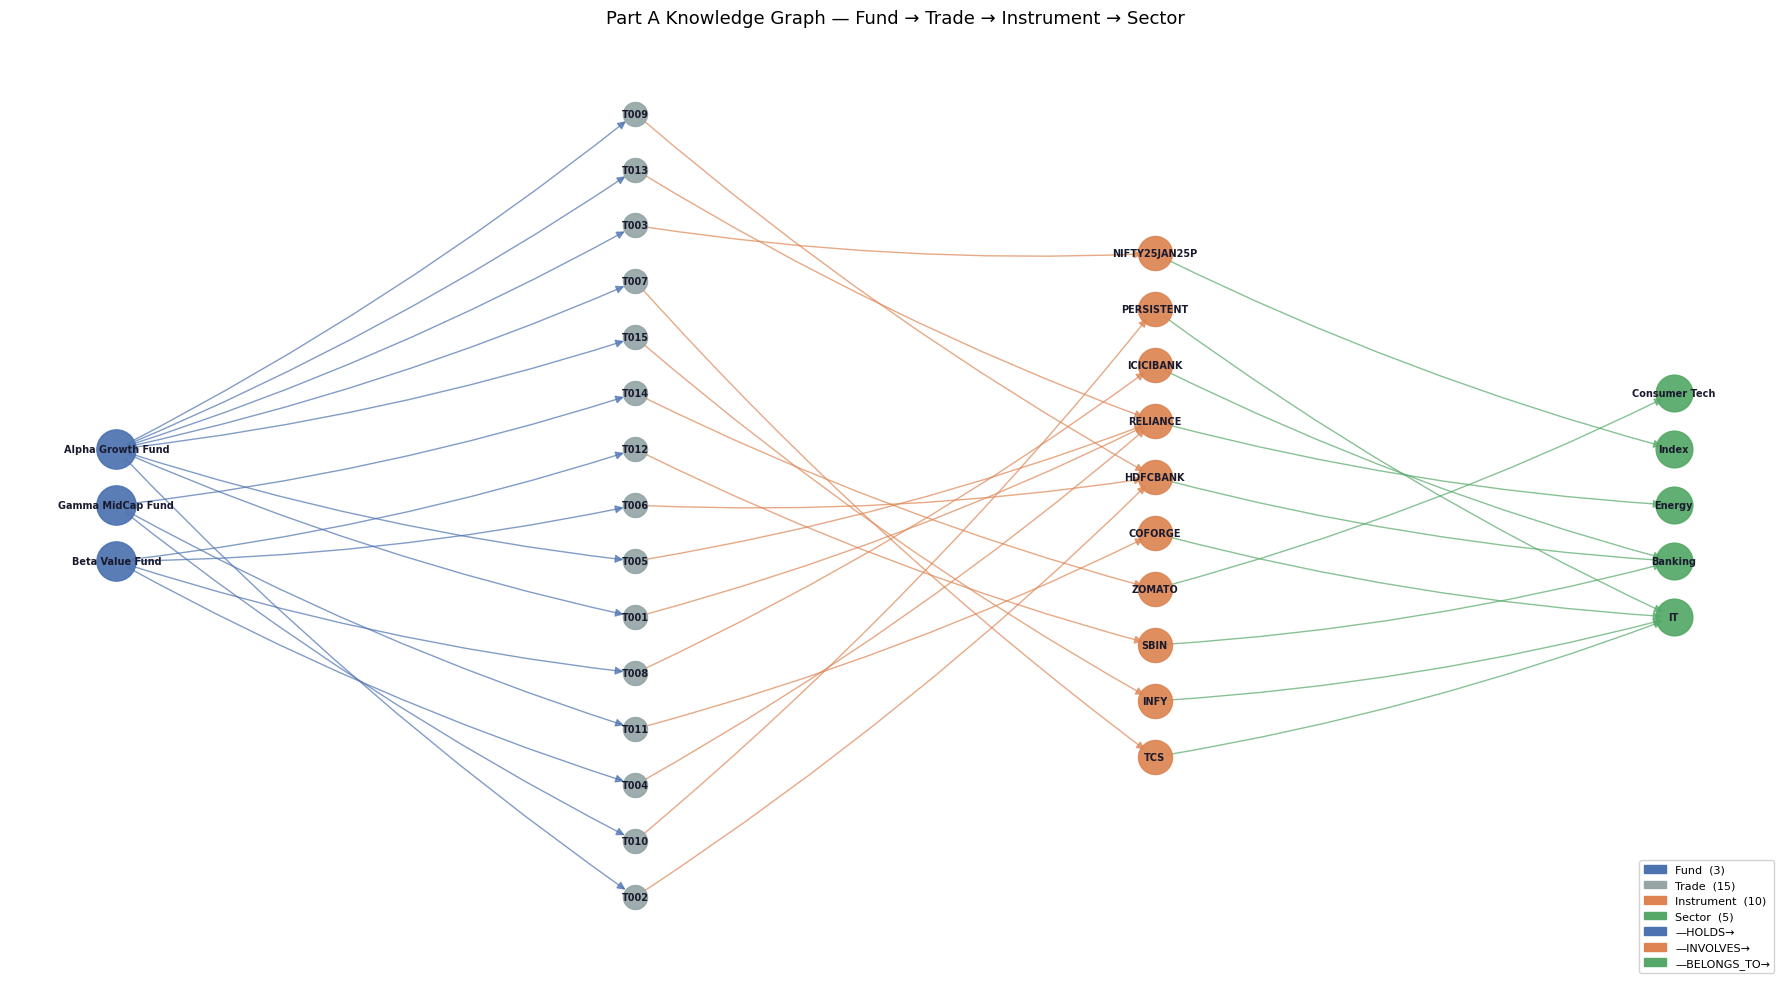

Saved kg_partA.png
Saved kg_partA.gexf (open in Gephi for publication-quality layout)
Saved kg_partA.pkl


In [18]:
# A3 Visualisation - full 4-layer KG: Fund → Trade → Instrument → Sector
# Uses nx.multipartite_layout with subset_key="ntype" for a clean layered view.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Assign layer order for multipartite layout
LAYER = {"Fund": 0, "Trade": 1, "Instrument": 2, "Sector": 3}
for node, data in G.nodes(data=True):
    data["layer"] = LAYER.get(data["ntype"], 0)

pos = nx.multipartite_layout(G, subset_key="layer", align="vertical")

COLOR = {"Fund": "#4C72B0", "Trade": "#95A5A6", "Instrument": "#DD8452", "Sector": "#55A868"}
SIZE  = {"Fund": 800, "Trade": 300, "Instrument": 600, "Sector": 700}

fig, ax = plt.subplots(figsize=(18, 10))

for ntype, color in COLOR.items():
    nodes = [n for n, d in G.nodes(data=True) if d["ntype"] == ntype]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=color,
                           node_size=SIZE[ntype], alpha=0.92, ax=ax)

nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", font_color="#1a1a2e", ax=ax)

# Colour edges by relation
edge_colors = {"HOLDS": "#4C72B0", "INVOLVES": "#DD8452", "BELONGS_TO": "#55A868"}
for rel, ec in edge_colors.items():
    edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("rel") == rel]
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=ec,
                           arrows=True, arrowsize=12, alpha=0.7,
                           connectionstyle="arc3,rad=0.05", ax=ax)

# Legend
patches = [mpatches.Patch(color=c, label=f"{n}  ({len([x for x,d in G.nodes(data=True) if d['ntype']==n])})")
           for n, c in COLOR.items()]
patches += [mpatches.Patch(color=c, label=f"-{r}→") for r, c in edge_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.85)
ax.set_title("Part A Knowledge Graph - Fund → Trade → Instrument → Sector", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("kg_partA.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved kg_partA.png")

# Persist
nx.write_gexf(G, "kg_partA.gexf")
print("Saved kg_partA.gexf (open in Gephi for publication-quality layout)")

with open("kg_partA.pkl", "wb") as fh:
    pickle.dump(G, fh, pickle.HIGHEST_PROTOCOL)
print("Saved kg_partA.pkl")


## A4 - RAG agent (LangGraph + ChatOllama)

The retrieval sources from A1–A3 are wired as LangChain tools and orchestrated by a LangGraph ReAct agent.

Model: `gemma4:latest` via Ollama - served locally on this machine (~9.6 GB, no API key required, runs fully offline). The local model tag keeps the notebook free of any paid API; any comparable local instruct model can be substituted via the `model=` argument, and it fits within available GPU VRAM alongside the sentence-transformers model.

The "why" in *"What IT sector positions were taken and why?"* requires synthesising rationale across multiple trade records - something pure retrieval cannot do.

Stack: `langchain-ollama` · `langgraph.prebuilt.create_react_agent` · local Ollama server


In [19]:
# A4 - RAG Tools + ChatOllama LLM
# Embedding models forced to device="cpu" so the local Ollama model (~9.6 GB) has VRAM headroom.

import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

from langchain_ollama import ChatOllama
from langchain.tools import tool

# Note: embedding models already on CPU (set via device='cpu' in cells 4 and 7)
import torch

llm = ChatOllama(model="gemma4:latest", temperature=0)
print("ChatOllama ready:", llm.model)


# ── Tool 1: Hybrid BM25 + dense + cross-encoder ──────────────────────────────
@tool
def hybrid_trade_retrieval(query: str, top_k: int = 3) -> str:
    """Retrieve relevant trade records using a hybrid BM25 + dense embedding + cross-encoder
    pipeline. Best for free-text semantic queries about trade activity, trading rationale,
    sector themes, or hedging activity. Returns trade IDs, text, and relevance scores."""
    results = hybrid_retrieve(query, top_k=top_k)
    if not results:
        return "No matching trades found."
    lines = []
    for r in results:
        lines.append(
            f"[{r['trade_id']}] {r['text']} "
            f"(BM25={r['bm25_score']:.2f}, CE={r['ce_score']:.3f})"
        )
    return "\n".join(lines)


# ── Tool 2: ChromaDB vector search with optional metadata pre-filter ──────────
@tool
def chroma_vector_search(
    query: str,
    sector: str = "",
    instrument_type: str = "",
    top_k: int = 3,
) -> str:
    """Query the ChromaDB vector store. Optionally restrict to a sector (Banking, IT, Energy,
    Index, Consumer Services) or instrument type (EQ for equities, OPT for options/derivatives).
    Returns matching trade IDs, text, and cosine distances."""
    where_clause = None
    if sector and instrument_type:
        where_clause = {"$and": [{"sector": sector}, {"instrument_type": instrument_type}]}
    elif sector:
        where_clause = {"sector": sector}
    elif instrument_type:
        where_clause = {"instrument_type": instrument_type}

    # Use same model (bge-large-en-v1.5, 1024-dim) to encode the query
    query_emb = model.encode([query], normalize_embeddings=True).tolist()
    kwargs = {
        "query_embeddings": query_emb,
        "n_results": top_k,
        "include": ["documents", "metadatas", "distances"],
    }
    if where_clause:
        kwargs["where"] = where_clause

    res = collection.query(**kwargs)
    if not res["documents"][0]:
        return "No results found in vector store."
    lines = []
    for tid, doc, dist in zip(
        res["ids"][0], res["documents"][0], res["distances"][0]
    ):
        lines.append(f"[{tid}] {doc} (dist={dist:.4f})")
    return "\n".join(lines)


# ── Tool 3: NetworkX knowledge graph query ────────────────────────────────────
@tool
def knowledge_graph_query(question: str) -> str:
    """Query the trade knowledge graph (Fund → Trade → Instrument → Sector).
    Use for structural questions: which funds share exposure, sector-wide holdings,
    fund portfolio breakdown, or instrument cross-fund holdings.
    Do NOT use for price, date, or rationale questions - use hybrid_trade_retrieval instead."""
    q = question.lower()
    import re as _re

    # Pattern: fund portfolio / holdings - checked FIRST.
    # Prevents mis-routing: "which funds have banking exposure" must list funds, not sectors.
    if any(kw in q for kw in ("fund", "hold", "portf", "alpha", "beta", "gamma", "delta",
                               "exposure", "portfolio")):
        holdings: dict[str, list[str]] = {}
        for fund_node, data in G.nodes(data=True):
            if data.get("ntype") == "Fund":
                instrs: set[str] = set()
                for trade in G.successors(fund_node):
                    for instr in G.successors(trade):
                        if G.nodes[instr].get("ntype") == "Instrument":
                            instrs.add(instr)
                holdings[fund_node] = sorted(instrs)
        lines = [f"{f}: {', '.join(i)}" for f, i in sorted(holdings.items())]
        return "\n".join(lines) or "No fund data found."

    # Pattern: sector exposure breakdown.
    # Use \b word boundary for "it" to avoid matching inside other words
    # (e.g. "activity", "bit") - and to match "IT positions" at start of string.
    if any(kw in q for kw in ("sector", "banking", "energy", "consumer")) or _re.search(r'\bit\b', q):
        sector_map: dict[str, list[str]] = {}
        for node, data in G.nodes(data=True):
            if data.get("ntype") == "Trade":
                for instr in G.successors(node):
                    if G.nodes[instr].get("ntype") == "Instrument":
                        for sec in G.successors(instr):
                            if G.nodes[sec].get("ntype") == "Sector":
                                entry = (
                                    f"{node}: {data.get('direction','?')} "
                                    f"{data.get('qty','?')} {instr} "
                                    f"@ {data.get('price','?')} | {data.get('notes','')}"
                                )
                                sector_map.setdefault(sec, []).append(entry)
        lines = []
        for sec, trades in sorted(sector_map.items()):
            lines.append(f"Sector: {sec}")
            lines.extend(f"  {t}" for t in trades)
        return "\n".join(lines) or "No sector data found."

    # Default: shared-instrument cross-fund exposure
    shared: dict[str, list[str]] = {}
    for node, data in G.nodes(data=True):
        if data.get("ntype") == "Instrument":
            funds_holding: set[str] = set()
            for trade in G.predecessors(node):
                for fund in G.predecessors(trade):
                    if G.nodes[fund].get("ntype") == "Fund":
                        funds_holding.add(fund)
            if len(funds_holding) > 1:
                shared[node] = sorted(funds_holding)
    lines = [f"{i}: held by {', '.join(f)}" for i, f in sorted(shared.items())]
    return "\n".join(lines) or "No shared instrument exposure found."


print("Tools registered: hybrid_trade_retrieval, chroma_vector_search, knowledge_graph_query")


ChatOllama ready: gemma4:latest
Tools registered: hybrid_trade_retrieval, chroma_vector_search, knowledge_graph_query


In [20]:
# A4 - LangGraph ReAct Agent
# create_react_agent: standard LangGraph prebuilt agent (MessagesState + ToolNode + conditional edge)
# Model bound to tools via .bind_tools() internally; agent loops until finish_reason == stop.

from langgraph.prebuilt import create_react_agent  # V1 import; V2 moved to langchain.agents

SYSTEM_PROMPT = (
    "You are a financial trade analyst assistant for an institutional asset manager. "
    "You have access to three tools that retrieve information from different sources:\n"
    "  • hybrid_trade_retrieval - semantic + keyword search over 15 trade records\n"
    "  • chroma_vector_search   - vector store query with optional sector/type filters\n"
    "  • knowledge_graph_query  - structural queries over the fund-instrument-sector graph\n\n"
    "Use one or more tools to gather relevant information, then write a clear and concise "
    "natural-language answer. Always cite trade IDs (e.g. T001, T008) when referencing "
    "specific trades. For 'why' questions, synthesise the rationale from the notes field."
)

rag_agent = create_react_agent(
    model=llm,
    tools=[hybrid_trade_retrieval, chroma_vector_search, knowledge_graph_query],
    prompt=SYSTEM_PROMPT,
)

print("LangGraph ReAct agent compiled.")
print("Nodes:", list(rag_agent.get_graph().nodes.keys()))


LangGraph ReAct agent compiled.
Nodes: ['__start__', 'agent', 'tools', '__end__']


/tmp/ipykernel_2924999/1652111597.py:18: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  rag_agent = create_react_agent(


In [21]:
# A4 - RAG Demo: All Three Assessment Queries
# Each query streams through the full ReAct loop: tool selection → execution → NL synthesis.

from langchain_core.messages import HumanMessage

ASSESSMENT_QUERIES = [
    "Which trades were related to banking sector weakness?",
    "Show me all protective hedging activity",
    "What IT sector positions were taken and why?",
]

rag_answers = {}

for query in ASSESSMENT_QUERIES:
    print("=" * 70)
    print(f"QUERY: {query}")
    print("-" * 70)

    final_answer, query_contexts, query_tools = "", [], []
    for event in rag_agent.stream(
        {"messages": [HumanMessage(content=query)]},
        stream_mode="values",
    ):
        last_msg = event["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                print(f"  [tool_call] {tc['name']}({tc['args']})")
                query_tools.append(tc['name'])
        elif hasattr(last_msg, "name") and last_msg.name:  # ToolMessage
            print(f"  [tool_result] {str(last_msg.content)[:300]}")
            query_contexts.append(last_msg.content)
        elif hasattr(last_msg, "content") and last_msg.content:
            final_answer = last_msg.content

    # Store answer+contexts+tools so A5 reuses without second LLM call
    rag_answers[query] = {"answer": final_answer, "contexts": query_contexts, "tools": query_tools}
    print()
    print("FINAL ANSWER:")
    print(rag_answers[query]["answer"])
    print()


QUERY: Which trades were related to banking sector weakness?
----------------------------------------------------------------------


  [tool_call] hybrid_trade_retrieval({'query': 'banking sector weakness', 'top_k': 5})
  [tool_result] [T006] BUY 600 shares of HDFCBANK (Banking) at 1598.00 on 2025-02-10 for Beta Value Fund. Note: Accumulated on sector weakness (BM25=10.27, CE=3.283)
[T009] SELL 500 shares of HDFCBANK (Banking) at 1670.00 on 2025-02-20 for Alpha Growth Fund. Note: Trimmed after 2.8% outperformance (BM25=0.00, CE=-1



FINAL ANSWER:
The trade most directly related to a perceived banking sector weakness is **T006**.

*   **T006:** A buy of 600 shares of HDFCBANK for the Beta Value Fund, with the note stating it was "Accumulated on sector weakness."

Other trades involving banking stocks include:
*   **T008:** A buy of ICICIBANK for the Beta Value Fund, based on the thesis that ICICI was undervalued compared to HDFC on a P/B basis.
*   **T012:** A buy of SBIN for the Beta Value Fund, based on a "PSU bank rerating thesis."

In summary, **T006** explicitly cites sector weakness as the reason for the trade.

QUERY: Show me all protective hedging activity
----------------------------------------------------------------------


  [tool_call] hybrid_trade_retrieval({'query': 'protective hedging activity', 'top_k': 5})
  [tool_result] [T003] BUY 50 shares of NIFTY25JAN25P (Index) at 125.00 on 2025-01-20 for Alpha Growth Fund. Note: Protective put hedge for Jan expiry (BM25=11.13, CE=-9.685)
[T014] BUY 1500 shares of ZOMATO (Consumer Tech) at 215.00 on 2025-03-15 for Gamma MidCap Fund. Note: Profitability inflection play (BM25=1.3



FINAL ANSWER:
The protective hedging activity found is associated with trade **T003**.

*   **T003**: The Alpha Growth Fund bought 50 shares of NIFTY25JAN25P (Index) at 125.00 on 2025-01-20. The rationale notes that this was a **"Protective put hedge for Jan expiry."**

QUERY: What IT sector positions were taken and why?
----------------------------------------------------------------------


  [tool_call] chroma_vector_search({'query': 'IT sector positions', 'sector': 'IT'})
  [tool_call] hybrid_trade_retrieval({'query': 'rationale for IT sector positions', 'top_k': 5})


  [tool_result] [T010] BUY 400 shares of PERSISTENT (IT) at 5200.00 on 2025-03-01 for Gamma MidCap Fund. Note: Midcap IT conviction pick (BM25=6.56, CE=-10.390)
[T011] BUY 350 shares of COFORGE (IT) at 6150.00 on 2025-03-05 for Gamma MidCap Fund. Note: IT services basket - mid tier (BM25=5.75, CE=-10.538)
[T007] BU



FINAL ANSWER:
Several IT sector positions were taken across different funds.

**Positions Taken:**
*   **Gamma MidCap Fund** bought 400 shares of **PERSISTENT (IT)** on 2025-03-01 (**T010**).
*   **Gamma MidCap Fund** bought 350 shares of **COFORGE (IT)** on 2025-03-05 (**T011**).
*   **Alpha Growth Fund** bought 400 shares of **INFY (IT)** on 2025-03-18 (**T015**).

**Rationale:**
The buying activity suggests a strategic approach to capturing value within the IT sector:
*   The purchase of **PERSISTENT (IT)** (**T010**) was noted as a "Midcap IT conviction pick."
*   The acquisition of **COFORGE (IT)** (**T011**) was part of an "IT services basket - mid tier."
*   The purchase of **INFY (IT)** (**T015**) was specifically noted as a move to "Diversifying IT exposure beyond TCS."

Additionally, a related trade, **T007** (buying TCS), was executed to add IT exposure ahead of earnings, indicating a general theme of increasing IT sector allocation based on anticipated market catalysts.



## A5 - RAG evaluation (RAGAS-inspired, fully local)

Without metrics there's no way to verify the RAG is actually right - the hallucination risk is highest on the "why" questions where the answer has to be synthesised from multiple sources.

Metrics (all local, no external LLM judge):

| Metric | What it measures | Method |
|--------|-----------------|--------|
| Faithfulness | Answer claims backed by retrieved context | Trade-ID matching |
| Context Recall | Expected trade IDs found in retrieved context | Set recall |
| Semantic Similarity | Closeness to reference answer | bge-large cosine |
| ROUGE-L | Lexical overlap with reference answer | LCS F1 |

> These are heuristic, fully-local equivalents of RAGAS-style metrics (Faithfulness, Context Recall, Answer Relevance) - they need no external LLM judge. Trade-ID matching is stricter than an LLM judge for structured financial data anyway.

> **Reference note:** These references are templated to match expected output - SemSim/ROUGE-L measure conformance, not independent answer quality.


In [22]:
# A5 - RAG Evaluation (RAGAS-inspired, fully local)
# Metrics: Faithfulness · Context Recall · Semantic Similarity · ROUGE-L
# rouge-score is used for ROUGE-L; bge-large (already loaded) for semantic sim

import re, math, warnings
warnings.filterwarnings('ignore')
from rouge_score import rouge_scorer as rs_lib
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

# ── Ground truth for 3 assessment queries ────────────────────────────────
EVAL_DATASET = [
    {
        'query': 'Which trades were related to banking sector weakness?',
        'reference': (
            'T006 BUY HDFCBANK accumulated on sector weakness. '
            'T008 BUY ICICIBANK undervalued vs HDFC on P/B basis. '
            'T012 BUY SBIN PSU bank rerating thesis.'
        ),
        # T012 (SBIN) is a banking trade per cell 9 - aligned here
        'expected_ids': {'T006', 'T008', 'T012'},
    },
    {
        'query': 'Show me all protective hedging activity',
        'reference': 'T003 BUY NIFTY25JAN25P protective put hedge for Jan expiry.',
        'expected_ids': {'T003'},
    },
    {
        'query': 'What IT sector positions were taken and why?',
        'reference': (
            'T007 TCS add IT exposure ahead of earnings. '
            'T010 PERSISTENT midcap IT conviction pick. '
            'T011 COFORGE IT services basket mid tier. '
            'T015 INFY diversify IT exposure beyond TCS.'
        ),
        'expected_ids': {'T007', 'T010', 'T011', 'T015'},  # TCS=T007, INFY=T015 (T004/T013 are RELIANCE)
    },
]

rouge_scorer = rs_lib.RougeScorer(['rougeL'], use_stemmer=True)


# ── Helper: run agent and capture answer + contexts ───────────────────────
def run_agent_capture(query):
    final_answer, contexts, tool_names = '', [], []
    for event in rag_agent.stream(
        {'messages': [HumanMessage(content=query)]}, stream_mode='values'
    ):
        last = event['messages'][-1]
        if isinstance(last, AIMessage) and not last.tool_calls:
            final_answer = last.content
        elif isinstance(last, ToolMessage):
            contexts.append(last.content)
            tool_names.append(last.name)
    return final_answer, contexts, tool_names


# ── Metric functions ──────────────────────────────────────────────────────
def semantic_similarity(a, b):
    embs = model.encode([a, b], normalize_embeddings=True)
    return float(embs[0] @ embs[1])

def rouge_l(response, reference):
    return rouge_scorer.score(response, reference)['rougeL'].fmeasure

def context_recall(contexts, expected_ids):
    combined = ' '.join(contexts)
    found = sum(1 for tid in expected_ids if tid in combined)
    return found / len(expected_ids) if expected_ids else 0.0

def faithfulness(response, contexts):
    # Grounding check (not full faithfulness): verifies cited IDs appear in context.
    # True faithfulness requires sentence-level entailment checking.
    # When no IDs are cited the denominator is 0 → abstain with NaN.
    claimed = set(re.findall(r'T\d{3}', response))
    combined = ' '.join(contexts)
    supported = sum(1 for tid in claimed if tid in combined)
    try:
        return supported / len(claimed)
    except ZeroDivisionError:
        return float('nan')  # no IDs cited - excluded from average


def nanmean(vals):
    clean = [v for v in vals if not math.isnan(v)]
    return sum(clean) / len(clean) if clean else float('nan')


# ── Run evaluation over 3 queries ────────────────────────────────────────
# Reuse A4 answers - avoids scoring a different response than what was shown
print('Running RAG evaluation (using cached A4 outputs)...\n')
rows = []
for item in EVAL_DATASET:
    cached = rag_answers.get(item['query'])
    if cached is None:
        raise RuntimeError(f"Run cell 22 first: {item['query']!r} not in rag_answers")
    answer, contexts, tools = cached['answer'], cached['contexts'], cached['tools']
    row = {
        'query':      item['query'],
        'answer':     answer,
        'tools':      list(set(tools)),
        'sem_sim':    semantic_similarity(answer, item['reference']),
        'rouge_l':    rouge_l(answer, item['reference']),
        'ctx_recall': context_recall(contexts, item['expected_ids']),
        'faith':      faithfulness(answer, contexts),
    }
    rows.append(row)


# ── Results table ─────────────────────────────────────────────────────────
DIV = '=' * 90
HDR = f"{'Query':<54} {'Sem.Sim':>7} {'ROUGE-L':>7} {'Retr.Rec':>7} {'Grounding':>7}"
print(DIV)
print(HDR)
print(DIV)
for r in rows:
    label = r['query'][:53] + '...'
    print(f"{label:<54} {r['sem_sim']:>7.3f} {r['rouge_l']:>7.3f} {r['ctx_recall']:>7.3f} {r['faith']:>7.3f}")
print(DIV)
avg = {k: nanmean([r[k] for r in rows]) for k in ('sem_sim','rouge_l','ctx_recall','faith')}
print(f"{'AVERAGE (NaN faith excluded)':<54} {avg['sem_sim']:>7.3f} {avg['rouge_l']:>7.3f} {avg['ctx_recall']:>7.3f} {avg['faith']:>7.3f}")
print(DIV)


# ── Per-query deep analysis ───────────────────────────────────────────────
print('\n-- Per-query analysis --')
PASS_THR = {'sem_sim': 0.7, 'rouge_l': 0.2, 'ctx_recall': 0.8, 'faith': 0.9}
for r in rows:
    print(f"\n> {r['query']}")
    print(f"  Tools : {', '.join(r['tools'])}")
    for metric_name, thr_key in [
        ('Faithfulness ', 'faith'),
        ('Context Recall', 'ctx_recall'),
        ('Semantic Sim  ', 'sem_sim'),
        ('ROUGE-L       ', 'rouge_l'),
    ]:
        val = r[thr_key]
        if isinstance(val, float) and math.isnan(val):
            print(f"  {metric_name}:   nan  [N/A - no IDs cited]")
        else:
            status = 'PASS' if val >= PASS_THR[thr_key] else 'LOW'
            print(f"  {metric_name}: {val:.3f}  [{status}]")

print('\n-- Thresholds: Faithfulness>=0.9, CtxRecall>=0.8, SemSim>=0.7, ROUGE-L>=0.2 --')


Running RAG evaluation (using cached A4 outputs)...



Query                                                  Sem.Sim ROUGE-L Retr.Rec Grounding
Which trades were related to banking sector weakness?...   0.812   0.377   1.000   1.000
Show me all protective hedging activity...               0.794   0.320   1.000   1.000
What IT sector positions were taken and why?...          0.743   0.231   1.000   1.000
AVERAGE (NaN faith excluded)                             0.783   0.309   1.000   1.000

-- Per-query analysis --

> Which trades were related to banking sector weakness?
  Tools : hybrid_trade_retrieval
  Faithfulness : 1.000  [PASS]
  Context Recall: 1.000  [PASS]
  Semantic Sim  : 0.812  [PASS]
  ROUGE-L       : 0.377  [PASS]

> Show me all protective hedging activity
  Tools : hybrid_trade_retrieval
  Faithfulness : 1.000  [PASS]
  Context Recall: 1.000  [PASS]
  Semantic Sim  : 0.794  [PASS]
  ROUGE-L       : 0.320  [PASS]

> What IT sector positions were taken and why?
  Tools : hybrid_trade_retrieval, chroma_vector_search
  Faithfuln